<a href="https://colab.research.google.com/github/AJasa1983/Assessment_Repo/blob/main/programmng_for_Data_Analysis_st20350980.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Setting up the Environment
#importing Libraries and Connect to Github

In [1]:
# ── IMPORTS ──────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from IPython.display import display

# Set a consistent visual style for all matplotlib/seaborn charts
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

print('All libraries imported successfully.')

All libraries imported successfully.


In [2]:
# ── GITHUB SETUP ─────────────────────────────────────────────────────────
# Configure Git identity — this is required so Git knows who is making commits
! git config --global user.name "AJasa1983"
! git config --global user.email "ofemomini60@gmail.com"

# Store your GitHub credentials
username = "AJasa1983"
repo     = "Assessment_Repo"

# Clone the repository if it hasn't been cloned yet in this session
# The '-f' flag in 'test -d' checks whether the folder already exists
import os
if not os.path.exists(repo):
    os.system(f'git clone https://github.com/{username}/{repo}')
    print(f'Cloned {repo} successfully.')
else:
    print(f'{repo} already exists — skipping clone.')

# Move into the repository folder so all file operations happen there
%cd {repo}
print('Working directory:', os.getcwd())

Cloned Assessment_Repo successfully.
/content/Assessment_Repo
Working directory: /content/Assessment_Repo


Merging the csv files

In [3]:
# LOAD & MERGE DATA
# ──────────────────────────────────────
# glob.glob finds all CSV files in the current directory
city_files = glob.glob('*.csv')
print(f'CSV files found: {city_files}')

# Read each file into a list, then concatenate into one DataFrame
all_data = []
for f in city_files:
    temp = pd.read_csv(f)
    all_data.append(temp)
    print(f'  Loaded {f} — {len(temp):,} rows')

# pd.concat stacks all DataFrames on top of each other (row-wise)
# ignore_index=True resets the index to be continuous 0, 1, 2 ...
df = pd.concat(all_data, ignore_index=True)

print(f'\nMerged dataset: {df.shape[0]:,} rows x {df.shape[1]} columns')

CSV files found: ['PRSA_Data_Huairou_20130301-20170228.csv', 'PRSA_Data_Shunyi_20130301-20170228.csv', 'PRSA_Data_Tiantan_20130301-20170228.csv', 'PRSA_Data_Dongsi_20130301-20170228.csv']
  Loaded PRSA_Data_Huairou_20130301-20170228.csv — 35,064 rows
  Loaded PRSA_Data_Shunyi_20130301-20170228.csv — 35,064 rows
  Loaded PRSA_Data_Tiantan_20130301-20170228.csv — 35,064 rows
  Loaded PRSA_Data_Dongsi_20130301-20170228.csv — 35,064 rows

Merged dataset: 140,256 rows x 18 columns


DATA UNERSTANDING

Before any Analysis, we need to understand what the Datasets looks like.
1. How many Eows and columns does it have?
2. What are the Data types of each column?
3. Are there any missing values we need to handle?
4. Statistical details about the ranges and distribution

In [4]:
# ── SHAPE & COLUMNS ────────────────────────────────────────────────

print('=' * 55)
print(f'  Total Rows    : {df.shape[0]:,}')
print(f'  Total Columns : {df.shape[1]}')
print('=' * 55)

# List of all column names so we know what variables are available
print('\nColumn Names:')
for i, col in enumerate(df.columns, 1):
    print(f'  {i:2}. {col}')

  Total Rows    : 140,256
  Total Columns : 18

Column Names:
   1. No
   2. year
   3. month
   4. day
   5. hour
   6. PM2.5
   7. PM10
   8. SO2
   9. NO2
  10. CO
  11. O3
  12. TEMP
  13. PRES
  14. DEWP
  15. RAIN
  16. wd
  17. WSPM
  18. station


In [ ]:
# DATA TYPES ─────────────────────────────────────────────────────
# this explains how pandas has interpreted each column.
# the 'int64' and 'float64' are numeric columns.
# object =(like station name or wind direction).

print('Column Data Types:')
print(df.dtypes)

print('\nFirst 15 rows of data:')
display(df.head(15))

Column Data Types:
No           int64
year         int64
month        int64
day          int64
hour         int64
PM2.5      float64
PM10       float64
SO2        float64
NO2        float64
CO         float64
O3         float64
TEMP       float64
PRES       float64
DEWP       float64
RAIN       float64
wd          object
WSPM       float64
station     object
dtype: object

First 15 rows of data:


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,7.0,7.0,3.0,2.0,100.0,91.0,-2.3,1020.3,-20.7,0.0,WNW,3.1,Huairou
1,2,2013,3,1,1,4.0,4.0,3.0,NaN,100.0,92.0,-2.7,1020.8,-20.5,0.0,NNW,1.5,Huairou
2,3,2013,3,1,2,4.0,4.0,NaN,NaN,100.0,91.0,-3.2,1020.6,-21.4,0.0,NW,1.8,Huairou
3,4,2013,3,1,3,3.0,3.0,3.0,2.0,NaN,NaN,-3.3,1021.3,-23.7,0.0,NNW,2.4,Huairou
4,5,2013,3,1,4,3.0,3.0,7.0,NaN,300.0,86.0,-4.1,1022.1,-22.7,0.0,NNW,2.2,Huairou
5,6,2013,3,1,5,4.0,4.0,3.0,3.0,200.0,85.0,-4.2,1022.3,-24.5,0.0,N,4.3,Huairou
6,7,2013,3,1,6,3.0,6.0,33.0,7.0,300.0,82.0,-5.9,1023.1,-21.9,0.0,WNW,0.6,Huairou
7,8,2013,3,1,7,3.0,10.0,13.0,13.0,400.0,71.0,-2.7,1024.3,-23.2,0.0,NNE,3.4,Huairou
8,9,2013,3,1,8,3.0,13.0,34.0,38.0,800.0,45.0,-1.6,1025.2,-23.5,0.0,NNE,4.6,Huairou
9,10,2013,3,1,9,17.0,36.0,50.0,28.0,700.0,60.0,-1.1,1025.4,-23.8,0.0,NE,4.9,Huairou


Columns with Missing Values:


,Missing Count,Missing %
CO,7923,5.65
NO2,5349,3.81
O3,4147,2.96
SO2,4057,2.89
PM2.5,3293,2.35
PM10,2475,1.76
wd,941,0.67
TEMP,142,0.10
PRES,144,0.10
DEWP,147,0.10


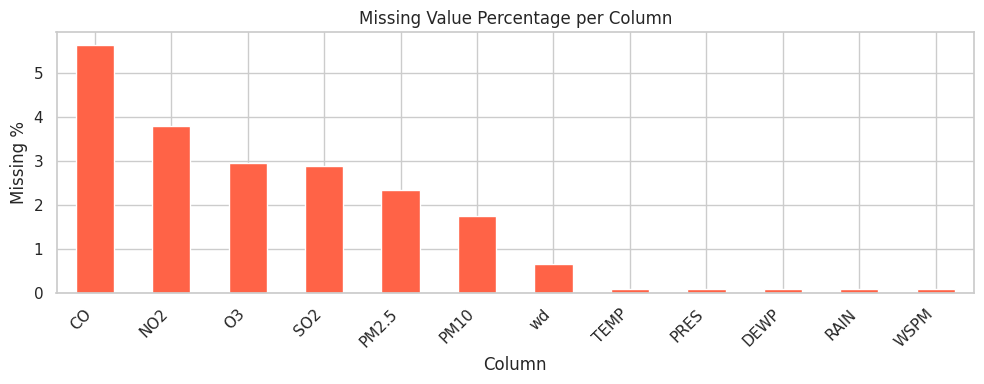

In [5]:
# ──MISSING VALUES ───────

missing_count = df.isnull().sum()
missing_pct   = (missing_count / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    'Missing Count' : missing_count,
    'Missing %'     : missing_pct
})

# Only show columns that actually have missing values
missing_report = missing_report[missing_report['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print('Columns with Missing Values:')
display(missing_report)

missing_report['Missing %'].plot(
    kind='bar', figsize=(10, 4), color='tomato', edgecolor='white'
)
plt.title('Missing Value Percentage per Column')
plt.xlabel('Column')
plt.ylabel('Missing %')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

OBSERVATIONS

* The combined Dataset has 140,256 hourly records across 4 stations between (2013 - 2017)
* Each station contributes 35,064 rows - the data is evenly distributed
* Pollutant columns (pm2.5, pm10, SO2, NO2, CO, 03) and metrological column (TEMP, PRES, DEWP, RAIN, WSPM) have varying amount of missing data.
* PM2.5 values have a high maximum, suggesting pluution spikes (outlier)
* Year ranges from 2013 - 2017; hour ranges from 0 to 23- hourly resolution
* The 'WD' column (Wind direction) is categoricaly (text), all others are numeric

In [6]:
# STATISTICAL SUMMARY ────────────────────────────────────────────
# shows count, mean, std deviation, min, max, and quartiles
# spotting outliers and understand ranges.

print('Statistical Summary of Numeric Columns:')
display(df.describe().round(2))

# How many records does each station have?
print('\nRecord Count per Station:')
print(df['station'].value_counts())

Statistical Summary of Numeric Columns:


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,140256.00,140256.00,140256.00,140256.00,140256.00,136963.00,137781.00,136199.00,134907.00,132333.00,136109.00,140114.00,140112.00,140109.00,140110.00,140135.00
mean,17532.50,2014.66,6.52,15.73,11.50,79.39,101.75,14.66,45.86,1208.21,57.06,13.29,1011.44,2.40,0.06,1.80
std,10122.14,1.18,3.45,8.80,6.92,80.42,90.54,20.58,32.15,1115.95,56.72,11.55,10.42,13.85,0.80,1.27
min,1.00,2013.00,1.00,1.00,0.00,2.00,2.00,0.29,1.03,100.00,0.21,-19.90,982.80,-43.40,0.00,0.00
25%,8766.75,2014.00,4.00,8.00,5.75,20.00,34.00,2.00,21.00,500.00,12.00,3.00,1003.00,-9.00,0.00,1.00
50%,17532.50,2015.00,7.00,16.00,11.50,55.00,80.00,6.00,39.00,900.00,45.00,14.30,1011.00,3.00,0.00,1.50
75%,26298.25,2016.00,10.00,23.00,17.25,111.00,141.00,18.00,64.00,1500.00,81.00,23.10,1019.70,15.10,0.00,2.30
max,35064.00,2017.00,12.00,31.00,23.00,941.00,999.00,315.00,258.00,10000.00,1071.00,41.10,1042.80,29.10,46.40,12.90



Record Count per Station:
station
Huairou    35064
Shunyi     35064
Tiantan    35064
Dongsi     35064
Name: count, dtype: int64


DATA PREPROCESSING

In this Section we will;
* Create a datetime column - combines year/month/day/hour into one proper     timestamp
* Remove duplicates - Avoid double-counting rows
* Handle missing values _ fills gaps using forwardf - fill (last known value) per station
* Feature engineering - Add useful new columns season, AQI category.

NOTE:
These steps ensures the data is clean, consistent and enriched for Analysis

In [7]:
# ── CREATE DATETIME COLUMN ─────────────────────────────────────────
# for time-based filtering, grouping, and plotting.

df['datetime'] = pd.to_datetime(
    df[['year', 'month', 'day', 'hour']]
)

# Set datetime as the index — useful for time-series operations
df = df.sort_values('datetime').reset_index(drop=True)

print('Datetime column sample:')
print(df[['year','month','day','hour','datetime']].head(3))
print(f'\nDate range: {df["datetime"].min()} → {df["datetime"].max()}')

Datetime column sample:
   year  month  day  hour   datetime
0  2013      3    1     0 2013-03-01
1  2013      3    1     0 2013-03-01
2  2013      3    1     0 2013-03-01

Date range: 2013-03-01 00:00:00 → 2017-02-28 23:00:00


In [8]:
# ── REMOVE DUPLICATES ───────────────────────────────────────────────
# Duplicate rows can skew statistics and model training, so We check and remove them here.

before = len(df)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
after = len(df)

print(f'Rows before deduplication : {before:,}')
print(f'Rows after  deduplication : {after:,}')
print(f'Duplicates removed        : {before - after}')

Rows before deduplication : 140,256
Rows after  deduplication : 140,256
Duplicates removed        : 0


In [21]:
# HANDLE MISSING VALUES ─

numeric_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3',
                'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']

df[numeric_cols] = (
    df.groupby('station')[numeric_cols]
      .transform(lambda x: x.ffill().bfill())
)

# Confirm missing values are resolved
remaining = df[numeric_cols].isnull().sum()
print('Missing values remaining after fill:')
print(remaining[remaining > 0] if remaining.sum() > 0 else 'None — all filled!')

Missing values remaining after fill:
None — all filled!


In [13]:
# FEATURE ENGINEERING — SEASON ───────────────────────────────────
# Seasons are important for air quality analysis because:
#   - Winter: coal heating increases PM2.5
#   - Summer: heat drives O3 formation
# We map month numbers to season names using a dictionary.

season_map = {
    12: 'Winter', 1: 'Winter',  2: 'Winter',
     3: 'Spring', 4: 'Spring',  5: 'Spring',
     6: 'Summer', 7: 'Summer',  8: 'Summer',
     9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
}
df['season'] = df['month'].map(season_map)

print('Season distribution:')
print(df['season'].value_counts())

Season distribution:
season
Spring    35328
Summer    35328
Autumn    34944
Winter    34656
Name: count, dtype: int64


In [10]:
# FEATURE ENGINEERING — AQI CATEGORY ───────────────────────

def aqi_category(pm25):
    """Classify PM2.5 value into an AQI health category."""
    if pd.isna(pm25):        return 'Unknown'
    elif pm25 <= 12.0:       return 'Good'
    elif pm25 <= 35.4:       return 'Moderate'
    elif pm25 <= 55.4:       return 'Unhealthy for Sensitive Groups'
    elif pm25 <= 150.4:      return 'Unhealthy'
    elif pm25 <= 250.4:      return 'Very Unhealthy'
    else:                    return 'Hazardous'

df['AQI_Category'] = df['PM2.5'].apply(aqi_category)

print('AQI Category distribution:')
print(df['AQI_Category'].value_counts())

AQI Category distribution:
AQI_Category
Unhealthy                         48625
Moderate                          30663
Good                              21929
Unhealthy for Sensitive Groups    17836
Very Unhealthy                    15010
Hazardous                          6193
Name: count, dtype: int64


In [14]:
# FEATURE ENGINEERING — STATION TYPE ───────────────────────
# pollution comparism levels between urban and suburban zones.

inner_stations = ['Dongsi', 'Tiantan']
df['station_type'] = df['station'].apply(
    lambda x: 'Inner (Urban)' if x in inner_stations else 'Outer (Suburban)'
)

print('Station type counts:')
print(df['station_type'].value_counts())

print('\nFinal dataset shape after preprocessing:', df.shape)
print('\nNew columns added: datetime, season, AQI_Category, station_type')
display(df[['datetime','station','station_type','season','AQI_Category','PM2.5']].head(5))

Station type counts:
station_type
Outer (Suburban)    70128
Inner (Urban)       70128
Name: count, dtype: int64

Final dataset shape after preprocessing: (140256, 22)

New columns added: datetime, season, AQI_Category, station_type


,datetime,station,station_type,season,AQI_Category,PM2.5
0,2013-03-01 00:00:00,Huairou,Outer (Suburban),Spring,Good,7.0
1,2013-03-01 00:00:00,Shunyi,Outer (Suburban),Spring,Good,3.0
2,2013-03-01 00:00:00,Tiantan,Inner (Urban),Spring,Good,6.0
3,2013-03-01 00:00:00,Dongsi,Inner (Urban),Spring,Good,9.0
4,2013-03-01 01:00:00,Shunyi,Outer (Suburban),Spring,Good,12.0


STATISTICAL ANALYSIS & VISUALISATION

Right now the Data is clean, let's noe explore it visually and statistically...

* Univariate: This examines each variable individual (distribution)
* Bivariate: explore relationships between pairs of variables (scatter plots, box plots)
* Multivariate: examines multi variables together (heatmaps, grouped bar charts, time series)

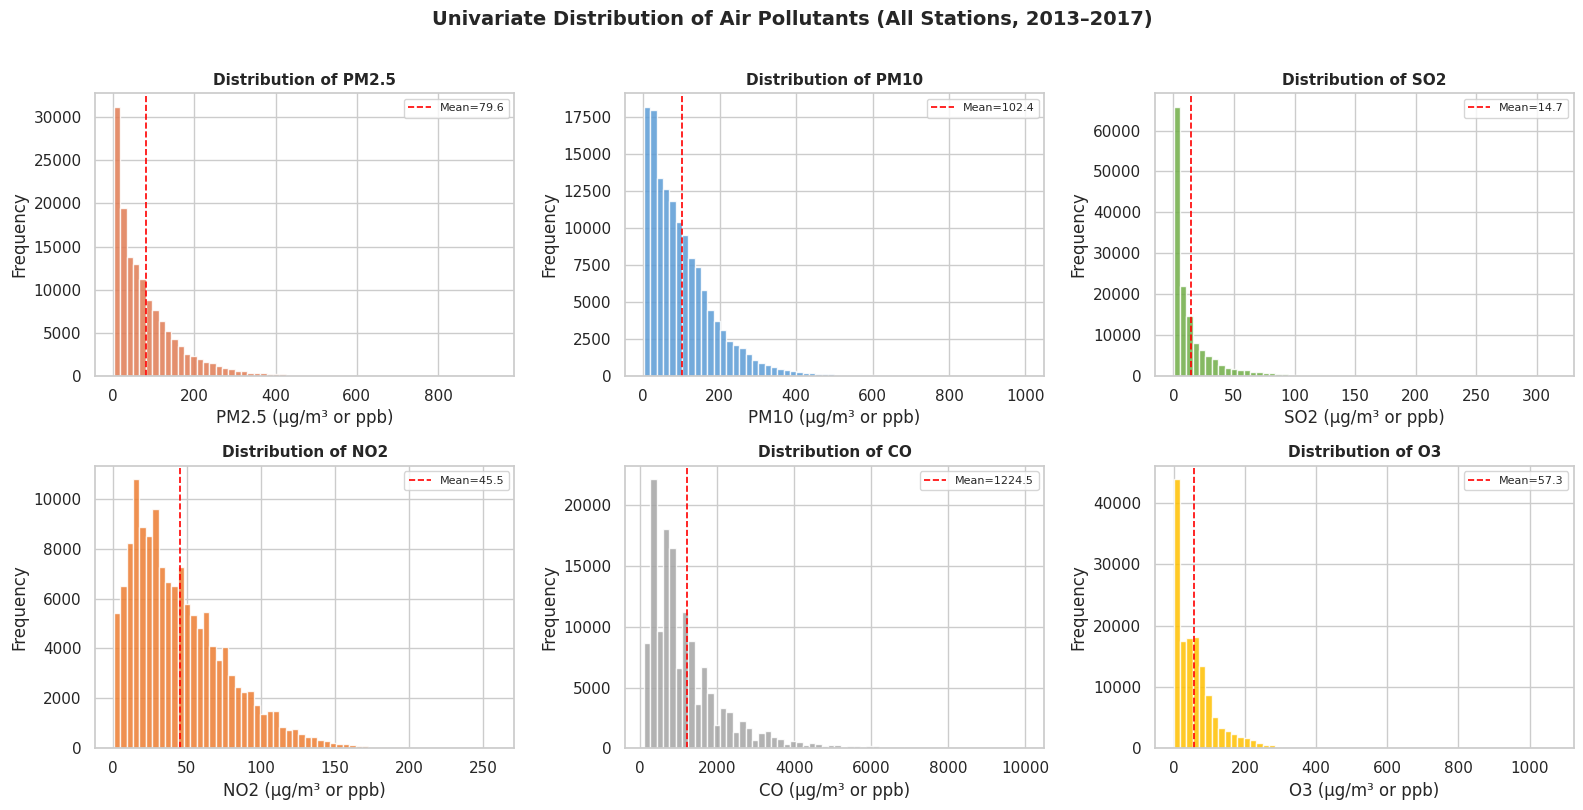

In [15]:
# UNIVARIATE — POLLUTANT DISTRIBUTIONS ───────────────────────────
# A histogram shows the frequency distribution of each pollutant.
# Skewed distributions (long right tails) indicate occasional high-pollution spikes.
# This is important for deciding how to handle outliers before model building.

pollutants = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

colors = ['#E07B54', '#5B9BD5', '#70AD47', '#ED7D31', '#A5A5A5', '#FFC000']

for i, col in enumerate(pollutants):
    axes[i].hist(df[col].dropna(), bins=60, color=colors[i], edgecolor='white', alpha=0.85)
    axes[i].set_title(f'Distribution of {col}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(f'{col} (µg/m³ or ppb)')
    axes[i].set_ylabel('Frequency')
    # Add a vertical line at the mean
    mean_val = df[col].mean()
    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=1.2, label=f'Mean={mean_val:.1f}')
    axes[i].legend(fontsize=8)

plt.suptitle('Univariate Distribution of Air Pollutants (All Stations, 2013–2017)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_01_pollutant_distributions.png', bbox_inches='tight')
plt.show()



THIS IS INTERPRETATION

All pollutant distributions are rigt - skewed (long tail on the right).
This means that most readings are low, but there are occasional extreme spikes.
CO has the widest spread, reflecting its link to traffic and combustion.
O3 shows a more symmetric distribution, infliuenced by photochemical reactions.

In [16]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


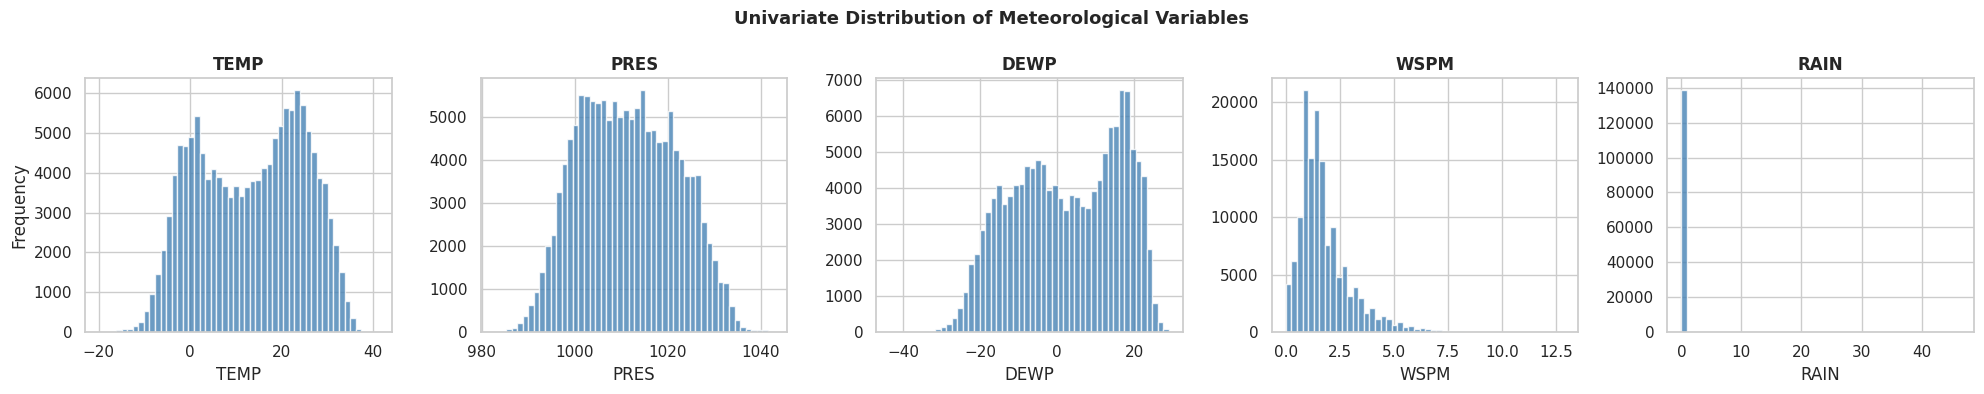

In [ ]:
# UNIVARIATE — METEOROLOGICAL VARIABLES
# Temperature, pressure, dew point, wind speed and rainfall all influence how pollutants disperse or accumulate. Understanding their distributions


met_vars = ['TEMP', 'PRES', 'DEWP', 'WSPM', 'RAIN']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, col in enumerate(met_vars):
    axes[i].hist(df[col].dropna(), bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency' if i == 0 else '')

plt.suptitle('Univariate Distribution of Meteorological Variables', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_02_met_distributions.png', bbox_inches='tight')
plt.show()






INTERPRETATION:

TEMP (Temperature):
The distribution is bimodal, showing two distinct peaks. This reflects
the natural seasonal cycle across the 4-year dataset (2013-2017), where
summer temperatures cluster around 25-35°C and winter temperatures cluster
around -5 to 5°C. The wide spread confirms strong seasonal variation in
Beijing, which is directly linked to pollution patterns — cold winters
drive heating emissions that elevate PM2.5.

PRES (Atmospheric Pressure):
Pressure follows a near-normal (bell-shaped) distribution, centred around
1010-1020 hPa. This is the expected behaviour for atmospheric pressure at
Beijing's altitude. High-pressure systems are associated with stable, calm
weather conditions that trap pollutants near the surface, making pressure
a useful predictor of air quality events.

DEWP (Dew Point):
The dew point distribution is broad and relatively flat, spanning from
approximately -30°C to 25°C. Like temperature, it reflects seasonal
variation — high dew points in summer indicate humid conditions while
negative values in winter reflect cold, dry air. Dew point is closely
linked to temperature and humidity, both of which influence how pollutants
form and disperse in the atmosphere.

WSPM (Wind Speed):
Wind speed is strongly right-skewed, meaning the vast majority of hourly
readings are calm or low (0-3 m/s), with only rare high-speed events
extending the tail to the right. This is a critical finding for air
quality analysis — low wind speeds reduce the horizontal dispersal of
pollutants, allowing PM2.5 and other pollutants to accumulate near the
surface. This helps explain the frequency of high-pollution episodes
seen in the dataset.

RAIN (Rainfall):
Rainfall shows the most extreme right-skew of all five variables. The
overwhelming majority of hourly records show zero or near-zero rainfall,
with only occasional heavy precipitation events. This is significant
because rainfall acts as a natural air cleaner through wet deposition —
raindrops absorb and remove particulate matter from the atmosphere.
The rarity of rain in Beijing, particularly in winter and spring, means
this natural cleaning mechanism is infrequent, contributing to prolonged
periods of elevated PM2.5.

OVERALL OBSERVATION:
The dominance of calm, dry conditions (low WSPM, near-zero RAIN) in the
dataset suggests that Beijing's atmosphere frequently lacks the natural
mechanisms needed to disperse or remove pollutants. Combined with cold
winter temperatures that drive heating emissions, these meteorological
conditions create the ideal environment for severe air pollution episodes.
